<a href="https://colab.research.google.com/github/Osaretin226/fatigue-predictor/blob/main/Cognitive_fatigue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Mock data — 15 trials with reaction time, error rate, and session duration
data = {
    'trial_id': list(range(1, 16)),
    'reaction_time_ms': [420, 450, 610, 580, 390, 720, 680, 410, 590, 750, 430, 640, 400, 700, 460],
    'error_rate': [0.05, 0.08, 0.22, 0.19, 0.04, 0.31, 0.28, 0.06, 0.20, 0.35, 0.07, 0.25, 0.05, 0.30, 0.09],
    'session_minutes': [10, 15, 45, 40, 8, 55, 50, 12, 42, 58, 10, 48, 9, 52, 14]
}

df = pd.DataFrame(data)
print(df)

    trial_id  reaction_time_ms  error_rate  session_minutes
0          1               420        0.05               10
1          2               450        0.08               15
2          3               610        0.22               45
3          4               580        0.19               40
4          5               390        0.04                8
5          6               720        0.31               55
6          7               680        0.28               50
7          8               410        0.06               12
8          9               590        0.20               42
9         10               750        0.35               58
10        11               430        0.07               10
11        12               640        0.25               48
12        13               400        0.05                9
13        14               700        0.30               52
14        15               460        0.09               14


In [3]:
df['fatigued'] = ((df['reaction_time_ms'] > 550) & (df['error_rate'] > 0.15)).astype(int)
print(df)

    trial_id  reaction_time_ms  error_rate  session_minutes  fatigued
0          1               420        0.05               10         0
1          2               450        0.08               15         0
2          3               610        0.22               45         1
3          4               580        0.19               40         1
4          5               390        0.04                8         0
5          6               720        0.31               55         1
6          7               680        0.28               50         1
7          8               410        0.06               12         0
8          9               590        0.20               42         1
9         10               750        0.35               58         1
10        11               430        0.07               10         0
11        12               640        0.25               48         1
12        13               400        0.05                9         0
13        14        

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features (the clues) and target (what we're predicting)
X = df[['reaction_time_ms', 'error_rate', 'session_minutes']]
y = df['fatigued']

# Split into training data (to learn from) and testing data (to check accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
model = LogisticRegression()
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Ask the model to predict on data it has never seen
predictions = model.predict(X_test)

# Compare predictions to the actual correct answers
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy * 100:.1f}%")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 100.0%

Confusion matrix:
[[1 0]
 [0 4]]


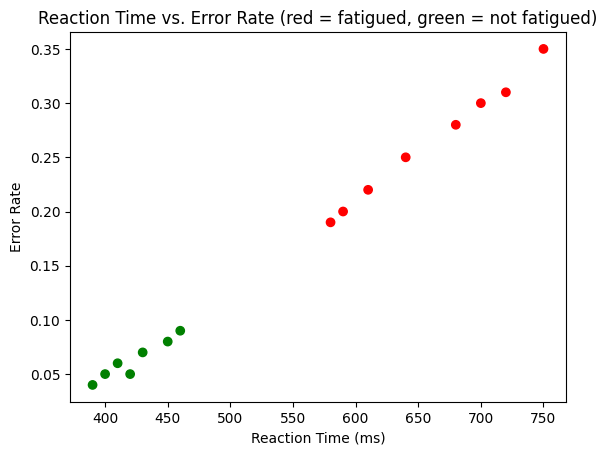

In [6]:
import matplotlib.pyplot as plt

colors = df['fatigued'].map({0: 'green', 1: 'red'})

plt.scatter(df['reaction_time_ms'], df['error_rate'], c=colors)
plt.xlabel('Reaction Time (ms)')
plt.ylabel('Error Rate')
plt.title('Reaction Time vs. Error Rate (red = fatigued, green = not fatigued)')
plt.show()